## Importing Libraries

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import re

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\affan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
data = pd.read_csv('./dataset.csv', encoding='latin-1', header=None)

data.head()


,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [4]:
data.sample(10)

,0,1,2,3,4,5
774734,0,2321622837,Wed Jun 24 21:19:22 PDT 2009,NO_QUERY,cutemixchick,I just wanna talk to somebody things are eas...
1542707,4,2181128075,Mon Jun 15 11:24:20 PDT 2009,NO_QUERY,lannenjay,@AliciaKLLmnstrs I didn't cut it! just have a ...
896755,4,1693120442,Sun May 03 21:37:10 PDT 2009,NO_QUERY,archangelmaggie,"@JennyGPA and i know, that would be horrible! ..."
657183,0,2240897157,Fri Jun 19 10:17:44 PDT 2009,NO_QUERY,lolakissesxo,@lovelylux LOL. At least they're not baby dadd...
1072463,4,1966577350,Fri May 29 18:01:20 PDT 2009,NO_QUERY,Stef3rz,@mileycyrus Whens your nexxxxtttt miley and ma...
485426,0,2181136047,Mon Jun 15 11:25:00 PDT 2009,NO_QUERY,dotfreedom,@STORMTRACKER_13 Are we ever gonna have a warm...
51188,0,1678840244,Sat May 02 07:51:50 PDT 2009,NO_QUERY,hope4theflowers,"Good morning, sunshine! It's finally a beauti..."
928568,4,1759618964,Sun May 10 19:36:44 PDT 2009,NO_QUERY,RavingMousette,O___O There's so much food here! :3 I would li...
841670,4,1563513655,Sun Apr 19 23:07:34 PDT 2009,NO_QUERY,lexayyy,@vsevani hey v! i hope all is well! San Diego ...
305140,0,1999917496,Mon Jun 01 21:03:38 PDT 2009,NO_QUERY,pinkstond,@andreajohnston I just seen your reply about t...


In [5]:
data.columns = ['sentiment','id','tweet_date','query','user_handle','text']

data.sample(5)

,sentiment,id,tweet_date,query,user_handle,text
903117,4,1694552279,Mon May 04 03:08:22 PDT 2009,NO_QUERY,linnetwoods,@paminnewzealand Hiya! You might want to delet...
726728,0,2262646857,Sat Jun 20 22:56:12 PDT 2009,NO_QUERY,happylookinfren,@theperfectlie the coursework too! its our sec...
1427328,4,2059366645,Sat Jun 06 16:47:23 PDT 2009,NO_QUERY,JenAvila,@From_The_Edge love my meat song. You are pret...
547040,0,2201955084,Tue Jun 16 21:01:19 PDT 2009,NO_QUERY,DiscoDeirdree,anyone know of anything that relieves stress t...
596089,0,2218924469,Wed Jun 17 23:25:32 PDT 2009,NO_QUERY,emilymarilyn,@karlythekarly I got 1! 3 bedroom 1 bath. Big ...


In [6]:
data['sentiment'].unique()

array([0, 4])

In [7]:
data.drop(columns=['id','tweet_date','query','user_handle'],inplace=True)

In [8]:
lab_to_sentiment = {0:"Negative", 4:"Positive"}
def label_decoder(label):
  return lab_to_sentiment[label]
data.sentiment = data.sentiment.apply(lambda x: label_decoder(x))
data.head()


,sentiment,text
0,Negative,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,Negative,is upset that he can't update his Facebook by ...
2,Negative,@Kenichan I dived many times for the ball. Man...
3,Negative,my whole body feels itchy and like its on fire
4,Negative,"@nationwideclass no, it's not behaving at all...."


In [16]:
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

print("train data size:", len(train_data))
print("test data size:", len(test_data))

train data size: 1280000
test data size: 320000


In [17]:
train_data.head(10)

,sentiment,text
1374558,Positive,jbtaylor ya quot like palm pre touchstone char...
1389115,Positive,felt earthquake afternoon seems epicenter
1137831,Positive,ruffles shirts like likey
790714,Negative,pretty bad night crappy morning fml buttface d...
1117911,Positive,dcbriccetti yeah clear view
1077663,Positive,one time follow fam ff georgeann13 nakithebeat...
1253991,Positive,msjbell u rock thanks added next robcrotch tm ...
1535242,Positive,ssnider yes please met fiancee ian party day b...
1396460,Positive,gawd finished whole bowl even posted previous ...
1178954,Positive,marty k awesome game short finish craving god ...


## Tokenization

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_data.text)

word_index = tokenizer.word_index
vocab_size = len(tokenizer.word_index)+1
print("Vocabulary Size: ", vocab_size)


Vocabulary Size:  565432


In [19]:
MAX_NB_WORDS = 100000
MAX_SEQUENCE_LENGTH = 30

In [20]:
from keras.preprocessing.sequence import pad_sequences

x_train = pad_sequences(tokenizer.texts_to_sequences(train_data.text),maxlen = MAX_SEQUENCE_LENGTH)
x_test = pad_sequences(tokenizer.texts_to_sequences(test_data.text),maxlen = MAX_SEQUENCE_LENGTH)

print("Training X shape: ",x_train.shape)
print("Testing X shape:  ", x_test.shape)

Training X shape:  (1280000, 30)
Testing X shape:   (320000, 30)


In [21]:
encoder = LabelEncoder()
encoder.fit(train_data.sentiment.to_list())

y_train = encoder.transform(train_data.sentiment.to_list())
y_test = encoder.transform(test_data.sentiment.to_list())

y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (1280000, 1)
y_test shape: (320000, 1)


In [22]:
labels = train_data.sentiment.unique().tolist()

In [23]:
labels

['Positive', 'Negative']

## Word Embedding

In [24]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2025-08-04 13:29:49--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-08-04 13:29:49--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-08-04 13:29:49--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
GLOVE_EMB = './glove.6B.300d.txt'
EMBEDDING_DIM = 300
LR = 1e-3
BATCH_SIZE = 1024
EPOCHS = 10
MODEL_PATH = './best_model.hdf5'


In [26]:
embeddings_index = {}

f = open(GLOVE_EMB)
for line in f:
  values = line.split()
  word = values[0]
  coefs = np.asarray(values[1:], dtype='float32')
  embeddings_index[word] = coefs
f.close()

print('Found %s word vectors.' %len(embeddings_index))

Found 400000 word vectors.


In [27]:
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
for word, i in word_index.items():
  embedding_vector = embeddings_index.get(word)
  if embedding_vector is not None:
    embedding_matrix[i] = embedding_vector

In [28]:
embedding_layer = tf.keras.layers.Embedding(vocab_size,
                                          EMBEDDING_DIM,
                                          weights=[embedding_matrix],
                                          input_length=MAX_SEQUENCE_LENGTH,
                                          trainable=False)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1754314396.624332      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1754314396.625065      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## LSTM

In [29]:
from tensorflow.keras.layers import Conv1D, Bidirectional, LSTM, Dense, Input, Dropout
from tensorflow.keras.layers import SpatialDropout1D
from tensorflow.keras.callbacks import ModelCheckpoint

In [30]:
sequence_input = Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='int32')
embedding_sequences = embedding_layer(sequence_input)
x = SpatialDropout1D(0.2)(embedding_sequences)
x = Conv1D(64, 5, activation='relu')(x)
x = Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2))(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(sequence_input, outputs)

In [31]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

model.compile(optimizer=Adam(learning_rate=LR), loss='binary_crossentropy',
              metrics=['accuracy'])
ReduceLROnPlateau = ReduceLROnPlateau(factor=0.1,
                                     min_lr = 0.01,
                                     monitor = 'val_loss',
                                     verbose = 1)


In [32]:
print("Training on GPU...") if tf.test.is_gpu_available() else print("Training on CPU...")

Training on GPU...


I0000 00:00:1754314400.771211      19 gpu_device.cc:2022] Created device /device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1754314400.771454      19 gpu_device.cc:2022] Created device /device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [33]:
history = model.fit(x_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS,
                    validation_data=(x_test, y_test), callbacks=[ReduceLROnPlateau])

Epoch 1/10


I0000 00:00:1754314411.263938      65 cuda_dnn.cc:529] Loaded cuDNN version 90300


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 123s 89ms/step - accuracy: 0.7139 - loss: 0.5488 - val_accuracy: 0.7652 - val_loss: 0.4824 - learning_rate: 0.0010
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 110s 88ms/step - accuracy: 0.7597 - loss: 0.4915 - val_accuracy: 0.7721 - val_loss: 0.4741 - learning_rate: 0.0010
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 111s 89ms/step - accuracy: 0.7672 - loss: 0.4795 - val_accuracy: 0.7757 - val_loss: 0.4672 - learning_rate: 0.0010
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 111s 89ms/step - accuracy: 0.7722 - loss: 0.4721 - val_accuracy: 0.7773 - val_loss: 0.4637 - learning_rate: 0.0010
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 111s 89ms/step - accuracy: 0.7754 - loss: 0.4671 - val_accuracy: 0.7787 - val_loss: 0.4638 - learning_rate: 0.0010
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 111s 88ms/step - accuracy: 0.7774 - loss: 0.4641 - val_accuracy: 0.7798 - val_loss: 0.4600 - learning_rate: 0.0010
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 110s 88ms/step - accuracy: 

## Evaluation

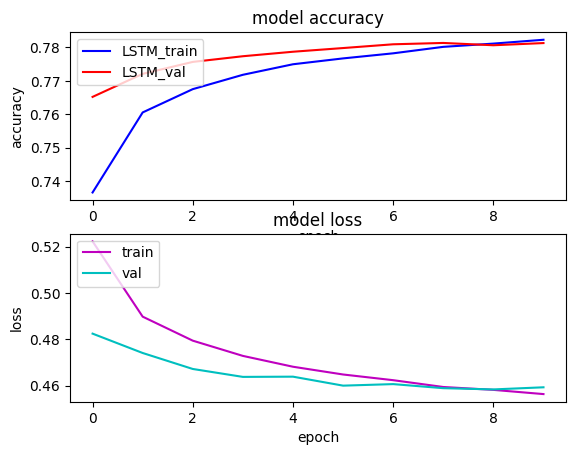

In [34]:
s, (at, al) = plt.subplots(2,1)
at.plot(history.history['accuracy'], c= 'b')
at.plot(history.history['val_accuracy'], c='r')
at.set_title('model accuracy')
at.set_ylabel('accuracy')
at.set_xlabel('epoch')
at.legend(['LSTM_train', 'LSTM_val'], loc='upper left')

al.plot(history.history['loss'], c='m')
al.plot(history.history['val_loss'], c='c')
al.set_title('model loss')
al.set_ylabel('loss')
al.set_xlabel('epoch')
al.legend(['train', 'val'], loc = 'upper left')

In [35]:
def decode_sentiment(score):
    return "Positive" if score>0.5 else "Negative"


scores = model.predict(x_test, verbose=1, batch_size=10000)
y_pred_1d = [decode_sentiment(score) for score in scores]

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step


## Confusion Matrix

In [36]:
import itertools
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
def plot_confusion_matrix(cm, classes,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """

    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=20)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=13)
    plt.yticks(tick_marks, classes, fontsize=13)

    fmt = '.2f'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label', fontsize=17)
    plt.xlabel('Predicted label', fontsize=17)


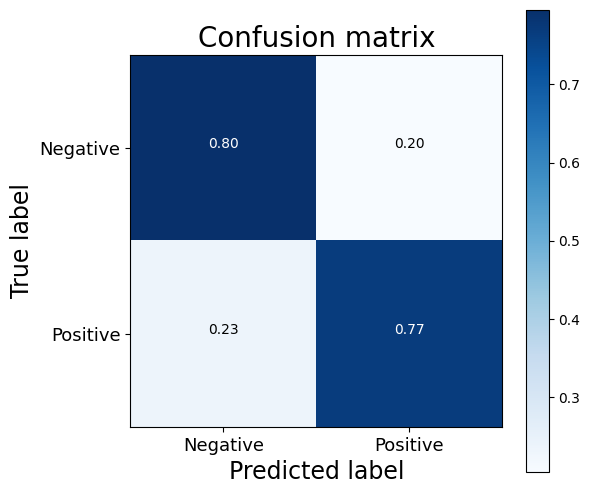

In [37]:
cnf_matrix = confusion_matrix(test_data.sentiment.to_list(), y_pred_1d)
plt.figure(figsize=(6,6))
plot_confusion_matrix(cnf_matrix, classes=test_data.sentiment.unique(), title="Confusion matrix")
plt.show()

In [38]:
print(classification_report(list(test_data.sentiment), y_pred_1d))

              precision    recall  f1-score   support

    Negative       0.77      0.80      0.78    159494
    Positive       0.79      0.77      0.78    160506

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000

